# 🎓 Projet : Prédiction de la Performance des Étudiants Marocains
**Équipe :** Squad 2 (Model Building)
**Date :** 10 Février 2026

## 🎯 Objectif
Développer et comparer plusieurs modèles de Machine Learning (Régression) pour prédire la note annuelle (`moyenne_annuelle`) en fonction des indicateurs académiques et socio-économiques.

## 📋 Sommaire
1. Chargement et exploration des données
2. Prétraitement (outliers, feature engineering, scaling, encoding, split)
3. Sélection de features (élimination du bruit)
4. Modélisation (8 modèles : LinearRegression, Ridge, Lasso, ElasticNet, RandomForest, GradientBoosting, XGBoost, MLP)
5. Comparaison des performances (R², RMSE, MAE)
6. Validation croisée (5-Fold)
7. Optimisation des hyperparamètres (RandomizedSearchCV)
8. Stacking Ensemble (combinaison des meilleurs modèles)
9. Analyse des résidus et importance des features
10. Diagnostic Overfitting / Underfitting (Validation Curves)
11. Interprétabilité (SHAP Values)
12. Courbes d'apprentissage (Learning Curves)
13. Sauvegarde du meilleur modèle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold,
    RandomizedSearchCV, learning_curve, validation_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Import des modèles
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, 
    StackingRegressor
)
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

# 1. Charger les données
df = pd.read_csv("../dataset/Morocco_Student_Data_Cleaned.csv")
print(f"✅ Données chargées : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"\n📋 Aperçu des premières lignes :")
display(df.head())
print(f"\n📊 Statistiques descriptives :")
display(df.describe())

✅ Données chargées : 10000 lignes, 268 colonnes

📋 Aperçu des premières lignes :


,id_etudiant,prenom,nom,nom_complet,sexe,date_naissance,age,code_massar,region,province,...,autre_langue,locuteur_amazigh,maitrise_darija,francais_maison,performance_cible,niveau_risque,intervention_necessaire,date_collecte,id_collecteur,statut_verification
0,STU00001,Soumia,Chraibi,Soumia Chraibi,F,2007-05-05,19,G548679848,Fes-Meknes,El Hajeb,...,Non,Natif,Rarement,Tres Eleve,0.54,Moyen,Oui,2026-01-15,COL008,Verifie
1,STU00002,Mehdi,Tazi,Mehdi Tazi,M,2009-10-12,17,G478451439,Souss-Massa,Inezgane,...,Oui,Natif,Parfois,Eleve,0.08,Eleve,Oui,2026-01-15,COL005,Verifie
2,STU00003,Bilal,Lahbabi,Bilal Lahbabi,M,2008-08-08,18,G727518594,Casablanca-Settat,Berrechid,...,Oui,Natif,Souvent,Tres Eleve,0.47,Eleve,Oui,2026-01-15,COL001,Verifie
3,STU00004,Hakim,Chraibi,Hakim Chraibi,M,2009-10-05,17,G868905524,Tanger-Tetouan-Al Hoceima,Larache,...,Non,Natif,Parfois,Eleve,0.55,Moyen,Oui,2026-01-15,COL008,Verifie
4,STU00005,Ayoub,Lahbabi,Ayoub Lahbabi,M,2007-05-27,19,G809425460,Casablanca-Settat,El Jadida,...,Non,Natif,Souvent,Eleve,0.15,Eleve,Oui,2026-01-15,COL004,Verifie



📊 Statistiques descriptives :


,age,code_postal,telephone,annee_inscription,revenu_mensuel_pere,revenu_mensuel_mere,telephone_tuteur,revenu_familial,nombre_freres_soeurs,rang_fratrie,...,tentatives_bac_precedentes,notes_examens_blancs,taux_assiduite,taux_ponctualite,taux_remise_devoirs,niveau_litteratie_numerique,competitions_scolaires,prix_recus,experience_stage,performance_cible
count,10000.000000,10000.000000,1.000000e+04,10000.0,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.00000,...,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,18.090400,52052.000000,6.551848e+08,2024.0,8859.259300,5718.875112,6.551801e+08,13889.203450,2.498700,2.29430,...,0.0,71.731200,89.219700,91.293700,82.897400,44.004200,2.891100,5.795900,58.58170,0.411558
std,0.789614,24579.420473,2.597032e+07,0.0,5472.455318,4226.069460,2.598213e+07,6960.873145,1.396063,1.21146,...,0.0,15.262432,6.541216,5.387072,10.152477,16.720046,1.959955,3.682798,34.29741,0.185743
min,17.000000,10000.000000,6.100040e+08,2024.0,0.000000,0.000000,6.100040e+08,0.000000,0.000000,1.00000,...,0.0,45.000000,78.000000,82.000000,65.000000,15.000000,0.000000,0.000000,0.00000,0.080000
25%,17.000000,31000.000000,6.327122e+08,2024.0,4613.750000,2643.000000,6.327300e+08,8567.750000,2.000000,1.00000,...,0.0,59.000000,84.000000,87.000000,74.000000,30.000000,1.000000,3.000000,29.00000,0.270000
50%,18.000000,52000.000000,6.552471e+08,2024.0,7337.000000,4746.000000,6.553210e+08,12773.500000,2.000000,2.00000,...,0.0,72.000000,89.000000,91.000000,83.000000,44.000000,3.000000,6.000000,58.00000,0.410000
75%,19.000000,73000.000000,6.776673e+08,2024.0,11850.250000,8229.250000,6.777016e+08,18292.750000,3.000000,3.00000,...,0.0,85.000000,95.000000,96.000000,92.000000,57.000000,5.000000,9.000000,88.00000,0.550000
max,19.000000,95000.000000,6.999856e+08,2024.0,22705.000000,16608.625000,6.999853e+08,32880.250000,6.000000,7.00000,...,0.0,98.000000,100.000000,100.000000,100.000000,75.000000,6.000000,12.000000,120.00000,0.990000


## 🛠 1. Prétraitement des Données (Preprocessing)

### 🧹 Détection et suppression des valeurs aberrantes (Outliers)
- **Méthode IQR** sur la variable cible `moyenne_annuelle`

### ⚠️ Sélection des variables (éviter le Data Leakage)
- **Exclues** : `moyenne_s1`, `moyenne_s2`, toutes les notes par matière (`*_s1`, `*_s2`, `*_annuel`), `performance_cible`, `rang_s1/s2/annuel` — car ce sont des composantes directes de `moyenne_annuelle`
- **Autorisées** : `moyenne_annee_precedente` et `rang_annee_precedente` — car elles proviennent de **l'année précédente** et ne constituent pas un Data Leakage

### 📊 Trois scénarios de prédiction :
| Scénario | Description | Variables |
|----------|-------------|----------|
| **1A** | Début d'année (socio-économique uniquement) | Variables socio-économiques + comportementales |
| **1B** | Début d'année (avec historique académique) | + `moyenne_annee_precedente` + `rang_annee_precedente` |
| **2** | Mi-année | + `moyenne_s1` |

### 🔧 Feature Engineering
- Création de nouvelles variables interactives

### Transformation
- *StandardScaler* pour les variables numériques
- *OneHotEncoder* pour les variables catégorielles

### Split : 80% entraînement / 20% test

🧹 Détection des valeurs aberrantes sur moyenne_annuelle...
   Bornes IQR : [5.51, 19.32]
   Valeurs aberrantes : 1 (0.0%)
   ✅ Après suppression : 9999 lignes


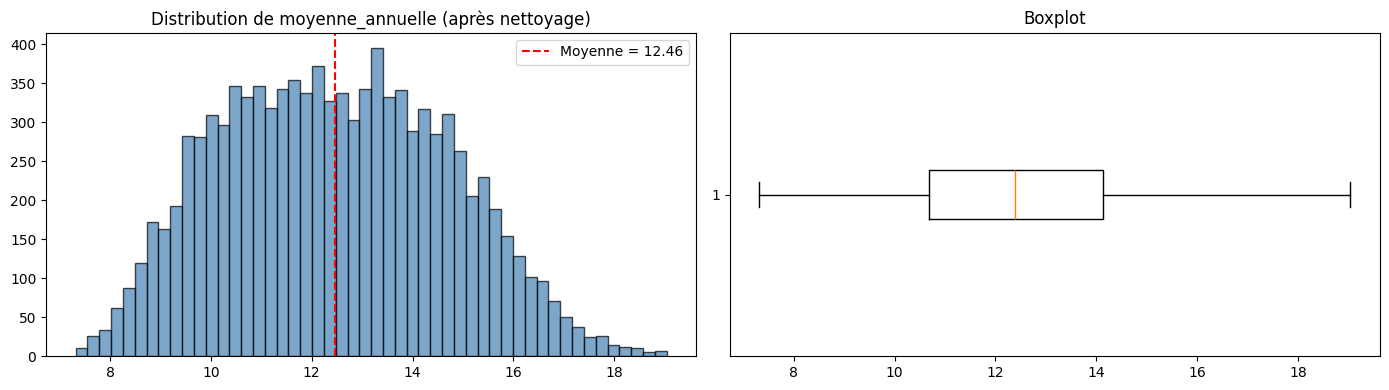


📌 Nombre de variables :
   Scénario 1A (socio uniquement) : 68
   Scénario 1B (avec historique)  : 70
   Scénario 2 (avec S1)           : 71

   Variables numériques (38)
   Variables catégorielles (32)

   Variables redondantes (|r| > 0.90) supprimées : ['total_heures_etude_semaine']

📊 Top 10 des variables les plus corrélées avec la cible :
   1. moyenne_annee_precedente                 r = +0.9576
   2. revenu_familial                          r = +0.3709
   3. revenu_par_personne                      r = +0.3342
   4. revenu_mensuel_pere                      r = +0.2547
   5. score_numerique                          r = +0.1418
   6. cout_mensuel_soutien                     r = +0.0673
   7. heures_soutien_semaine                   r = +0.0552
   8. sanctions                                r = +0.0506
   9. charge_parascolaire                      r = +0.0441
   10. jeux_video_heures_jour                   r = +0.0372

✅ Variables finales : 69

✅ Split effectué : entraînement = 79

In [2]:
# ==========================================
# 🧹 Étape 1 : Détection et suppression des valeurs aberrantes (Anti-Overfitting)
# ==========================================
print("🧹 Détection des valeurs aberrantes sur moyenne_annuelle...")
Q1 = df['moyenne_annuelle'].quantile(0.25)
Q3 = df['moyenne_annuelle'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_mask = (df['moyenne_annuelle'] < lower) | (df['moyenne_annuelle'] > upper)
n_outliers = outliers_mask.sum()
print(f"   Bornes IQR : [{lower:.2f}, {upper:.2f}]")
print(f"   Valeurs aberrantes : {n_outliers} ({n_outliers/len(df)*100:.1f}%)")

if n_outliers > 0:
    df = df[~outliers_mask].reset_index(drop=True)
    print(f"   ✅ Après suppression : {len(df)} lignes")
else:
    print("   ✅ Aucune valeur aberrante détectée")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['moyenne_annuelle'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Distribution de moyenne_annuelle (après nettoyage)')
axes[0].axvline(df['moyenne_annuelle'].mean(), color='red', linestyle='--', label=f"Moyenne = {df['moyenne_annuelle'].mean():.2f}")
axes[0].legend()
axes[1].boxplot(df['moyenne_annuelle'], vert=False)
axes[1].set_title('Boxplot')
plt.tight_layout()
plt.show()

# ==========================================
# 🎯 Étape 2 : Définition de la variable cible
# ==========================================
y = df["moyenne_annuelle"]

# ==========================================
# 📊 Étape 3 : Sélection des variables
# ==========================================
# --- [1A] Variables socio-économiques + comportementales + compétences (sans notes) ---
features_socio_base = [
    # --- Variables numériques ---
    "heures_etude_jour", "heures_etude_weekend",
    "absences_totales", "age", "distance_ecole_km",
    "revenu_familial", "nombre_freres_soeurs", "nombre_membres_famille",
    "heures_soutien_semaine", "heures_sommeil_semaine",
    "activite_physique_heures_semaine", "temps_ecran_heures_jour",
    "taux_assiduite", "taux_ponctualite", "taux_remise_devoirs",
    "annees_redoublement", "retards",
    # Nouvelles variables comportementales et de compétences
    "score_engagement", "score_feedback_enseignants", "score_collaboration",
    "effectif_classe", "avertissements", "sanctions",
    "nombre_livres", "cout_mensuel_soutien",
    "heures_sommeil_weekend", "reseaux_sociaux_heures_jour",
    "jeux_video_heures_jour", "lecture_heures_jour",
    "notes_examens_blancs",
    "revenu_mensuel_pere",
    
    # --- Variables catégorielles ---
    "sexe", "zone", "soutien_familial",
    "niveau", "filiere", "region",
    "niveau_education_pere", "niveau_education_mere",
    "statut_parental", "cours_particuliers",
    "niveau_motivation", "participation_classe", "attention_cours",
    "implication_parents", "confiance_en_soi",
    "internet", "chambre_personnelle", "ordinateur_portable",
    # Nouvelles variables catégorielles (compétences + comportement)
    "comportement", "prise_notes",
    "niveau_stress", "niveau_anxiete",
    "satisfaction_ecole", "satisfaction_enseignants",
    "efficacite_auto_apprentissage", "gestion_temps", "organisation",
    "resolution_problemes", "pensee_critique",
]

# --- [1B] Avec historique académique (année précédente) ---
# moyenne_annee_precedente et rang_annee_precedente ne sont pas du Data Leakage
# car ils proviennent de l'année précédente et sont disponibles avant les examens
features_with_history = features_socio_base + [
    "moyenne_annee_precedente",
    "rang_annee_precedente",
]

# --- [2] Mi-année (avec le semestre 1) ---
features_academique = features_with_history + ["moyenne_s1"]

# ==========================================
# 🚀 Feature Engineering
# ==========================================
df['revenu_par_personne'] = df['revenu_familial'] / (df['nombre_membres_famille'].replace(0, 1))
df['total_heures_etude_semaine'] = (df['heures_etude_jour'] * 5) + (df['heures_etude_weekend'] * 2)
df['ratio_etude_ecran'] = df['total_heures_etude_semaine'] / ((df['temps_ecran_heures_jour'] * 7) + 1)
df['indice_discipline'] = (df['taux_assiduite'] + df['taux_ponctualite'] + df['taux_remise_devoirs']) / 3
df['penalite_comportement'] = df['absences_totales'] + df['retards']
df['charge_parascolaire'] = df['heures_soutien_semaine'] + df['activite_physique_heures_semaine']
df['score_numerique'] = (df['internet'].map({'Oui':1,'Non':0}).fillna(0) + 
                         df['ordinateur_portable'].map({'Oui':1,'Non':0}).fillna(0) + 
                         df['chambre_personnelle'].map({'Oui':1,'Non':0}).fillna(0))
df['ratio_repos_activite'] = df['heures_sommeil_semaine'] / (df['total_heures_etude_semaine'] + 1)

nouvelles_features = [
    'revenu_par_personne', 'total_heures_etude_semaine', 'ratio_etude_ecran', 
    'indice_discipline', 'penalite_comportement', 'charge_parascolaire',
    'score_numerique', 'ratio_repos_activite'
]
features_socio_base.extend(nouvelles_features)
features_with_history = features_socio_base + ["moyenne_annee_precedente", "rang_annee_precedente"]
features_academique = features_with_history + ["moyenne_s1"]

# Vérification de l'existence des colonnes
features_socio_base = [c for c in features_socio_base if c in df.columns]
features_with_history = [c for c in features_with_history if c in df.columns]
features_academique = [c for c in features_academique if c in df.columns]

# ==========================================
# 🔍 Préparation du Scénario 1B (par défaut) comme scénario principal
# ==========================================
# Utilisation du Scénario 1B car la moyenne de l'année précédente est disponible et n'est pas du leakage
features_socio = features_with_history
X = df[features_socio]

print(f"\n📌 Nombre de variables :")
print(f"   Scénario 1A (socio uniquement) : {len(features_socio_base)}")
print(f"   Scénario 1B (avec historique)  : {len(features_with_history)}")
print(f"   Scénario 2 (avec S1)           : {len(features_academique)}")

# Séparation variables numériques et catégorielles
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\n   Variables numériques ({len(num_features)})")
print(f"   Variables catégorielles ({len(cat_features)})")

# Suppression des colonnes catégorielles à valeur unique
cols_to_remove = []
for col in cat_features:
    n_uniq = X[col].nunique()
    if n_uniq <= 1:
        print(f"   ⚠️ '{col}' n'a qu'une seule valeur -> supprimée")
        cols_to_remove.append(col)

for col in cols_to_remove:
    features_socio.remove(col)
    cat_features.remove(col)

X = df[features_socio]

# ==========================================
# 🔍 Suppression des variables redondantes (Anti-Overfitting)
# ==========================================
corr_matrix = X[num_features].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant_features = [col for col in upper_tri.columns if any(upper_tri[col] > 0.90)]
if redundant_features:
    print(f"\n   Variables redondantes (|r| > 0.90) supprimées : {redundant_features}")
    for col in redundant_features:
        if col in num_features: num_features.remove(col)
        if col in features_socio: features_socio.remove(col)
    X = df[features_socio]

# ==========================================
# 📊 Corrélation avec la variable cible  
# ==========================================
remaining_num = [f for f in num_features if f in X.columns]
corr_with_target = df[remaining_num + ['moyenne_annuelle']].corr()['moyenne_annuelle'].drop('moyenne_annuelle')
corr_with_target = corr_with_target.sort_values(ascending=False)

print(f"\n📊 Top 10 des variables les plus corrélées avec la cible :")
for i, (feat, corr) in enumerate(corr_with_target.head(10).items()):
    print(f"   {i+1}. {feat:<40} r = {corr:+.4f}")

print(f"\n✅ Variables finales : {len(features_socio)}")

# Recalcul après suppression
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
    ]
)

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n✅ Split effectué : entraînement = {X_train.shape[0]}, test = {X_test.shape[0]}")

## 🤖 2. Modélisation (Model Building) — Anti-Overfitting / Anti-Underfitting

Nous testons **8 algorithmes** avec des réglages optimisés pour le **biais-variance tradeoff** :

| # | Modèle | Stratégie Anti-Overfitting | Stratégie Anti-Underfitting |
|---|--------|---------------------------|----------------------------|
| 1 | **Régression Linéaire** | Baseline (pas de régularisation) | Modèle linéaire simple |
| 2 | **Ridge (L2)** | Régularisation L2 forte | — |
| 3 | **Lasso (L1)** | Régularisation L1 + sélection features | — |
| 4 | **ElasticNet (L1+L2)** | Combine L1 et L2 → le meilleur des deux | — |
| 5 | **Random Forest** | max_depth limité, min_samples_leaf élevé | Nombre d'arbres suffisant |
| 6 | **Gradient Boosting** | Shrinkage (learning_rate faible), early stopping | Boosting séquentiel |
| 7 | **XGBoost** | Régularisation L1+L2 + subsampling | Boosting + colsample |
| 8 | **MLP (Deep Learning)** | Dropout implicite, early stopping, alpha élevé | Architecture adaptée |

**Techniques Anti-Overfitting appliquées :**
- ✅ Régularisation (L1, L2, ElasticNet)
- ✅ Limitation complexité (max_depth, min_samples)
- ✅ Subsampling (bagging, row/column sampling)
- ✅ Early stopping (MLP, XGBoost)
- ✅ Cross-Validation systématique

**Techniques Anti-Underfitting appliquées :**
- ✅ Feature Engineering enrichi
- ✅ Modèles non-linéaires (RF, XGBoost, MLP)
- ✅ Ensemble Learning (Stacking)

In [3]:
# --- Définition de 8 modèles (équilibrés contre Overfitting + Underfitting) ---
# Avec la moyenne de l'année précédente (signal fort), on a besoin d'une
# régularisation forte pour éviter le surapprentissage tout en gardant
# des modèles suffisamment complexes pour bien apprendre

models = {
    # === Modèles linéaires ===
    "Régression Linéaire": LinearRegression(),

    "Ridge (L2)": Ridge(alpha=1.0),

    "Lasso (L1)": Lasso(alpha=0.01, max_iter=10000),

    "ElasticNet (L1+L2)": ElasticNet(
        alpha=0.05, l1_ratio=0.5, max_iter=10000
    ),

    # === Modèles Ensemble (Arbres) ===
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=8,            # Profondeur modérée
        min_samples_split=15,
        min_samples_leaf=8,
        max_features='sqrt',
        max_samples=0.8,        # Bagging 80%
        random_state=42, n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,     # Lent pour éviter l'Overfitting
        max_depth=4,
        min_samples_split=15,
        min_samples_leaf=8,
        subsample=0.8,          # Stochastic GB
        validation_fraction=0.1,
        n_iter_no_change=20,    # Early stopping
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        reg_alpha=1.0,          # L1
        reg_lambda=5.0,         # L2
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=5,
        gamma=0.5,
        random_state=42, n_jobs=-1
    ),

    # === Deep Learning ===
    "Deep Learning (MLP)": MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        alpha=0.5,
        learning_rate='adaptive',
        max_iter=2000,
        batch_size=64,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20
    )
}

# --- Entraînement et évaluation ---
results = []
trained_pipelines = {}

print("🚀 Entraînement de 8 modèles (Scénario 1B : début d'année + historique académique)...\n")
print(f"{'Modèle':<25} {'R²_test':>8} {'R²_train':>9} {'Écart':>7} {'RMSE':>8} {'MAE':>8} {'Diagnostic'}")
print("-" * 95)

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    gap = r2_train - r2_test

    results.append([name, rmse, mae, r2_test, r2_train])
    trained_pipelines[name] = pipeline

    # Diagnostic automatique
    if gap > 0.15:
        diag = "⚠️ OVERFITTING"
    elif gap > 0.05:
        diag = "⚡ Léger overfit"
    elif r2_test < 0.30:
        diag = "❌ UNDERFITTING"
    elif r2_test < 0.50:
        diag = "⚡ Léger underfit"
    else:
        diag = "✅ Équilibré"
    
    print(f"{name:<25} {r2_test:>8.4f} {r2_train:>9.4f} {gap:>+7.4f} {rmse:>8.4f} {mae:>8.4f} {diag}")

🚀 Entraînement de 8 modèles (Scénario 1B : début d'année + historique académique)...

Modèle                     R²_test  R²_train   Écart     RMSE      MAE Diagnostic
-----------------------------------------------------------------------------------------------
Régression Linéaire         0.9265    0.9321 +0.0056   0.5988   0.4996 ✅ Équilibré
Ridge (L2)                  0.9265    0.9321 +0.0055   0.5987   0.4996 ✅ Équilibré
Lasso (L1)                  0.9273    0.9307 +0.0034   0.5958   0.4985 ✅ Équilibré
ElasticNet (L1+L2)          0.9262    0.9295 +0.0034   0.6002   0.4987 ✅ Équilibré
Random Forest               0.7148    0.7497 +0.0349   1.1798   0.9572 ✅ Équilibré
Gradient Boosting           0.9285    0.9424 +0.0139   0.5907   0.4917 ✅ Équilibré
XGBoost                     0.9271    0.9490 +0.0219   0.5964   0.4938 ✅ Équilibré
Deep Learning (MLP)         0.9171    0.9470 +0.0299   0.6362   0.5223 ✅ Équilibré



📊 TABLEAU COMPARATIF FINAL :


,Modèle,RMSE,MAE,R² Test,R² Train
0,Gradient Boosting,0.590704,0.491710,0.928502,0.942361
1,Lasso (L1),0.595833,0.498528,0.927255,0.930702
2,XGBoost,0.596420,0.493807,0.927112,0.949000
3,Ridge (L2),0.598738,0.499578,0.926544,0.932090
4,Régression Linéaire,0.598755,0.499612,0.926540,0.932090
5,ElasticNet (L1+L2),0.600236,0.498665,0.926176,0.929544
6,Deep Learning (MLP),0.636150,0.522264,0.917077,0.946994
7,Random Forest,1.179818,0.957206,0.714778,0.749698


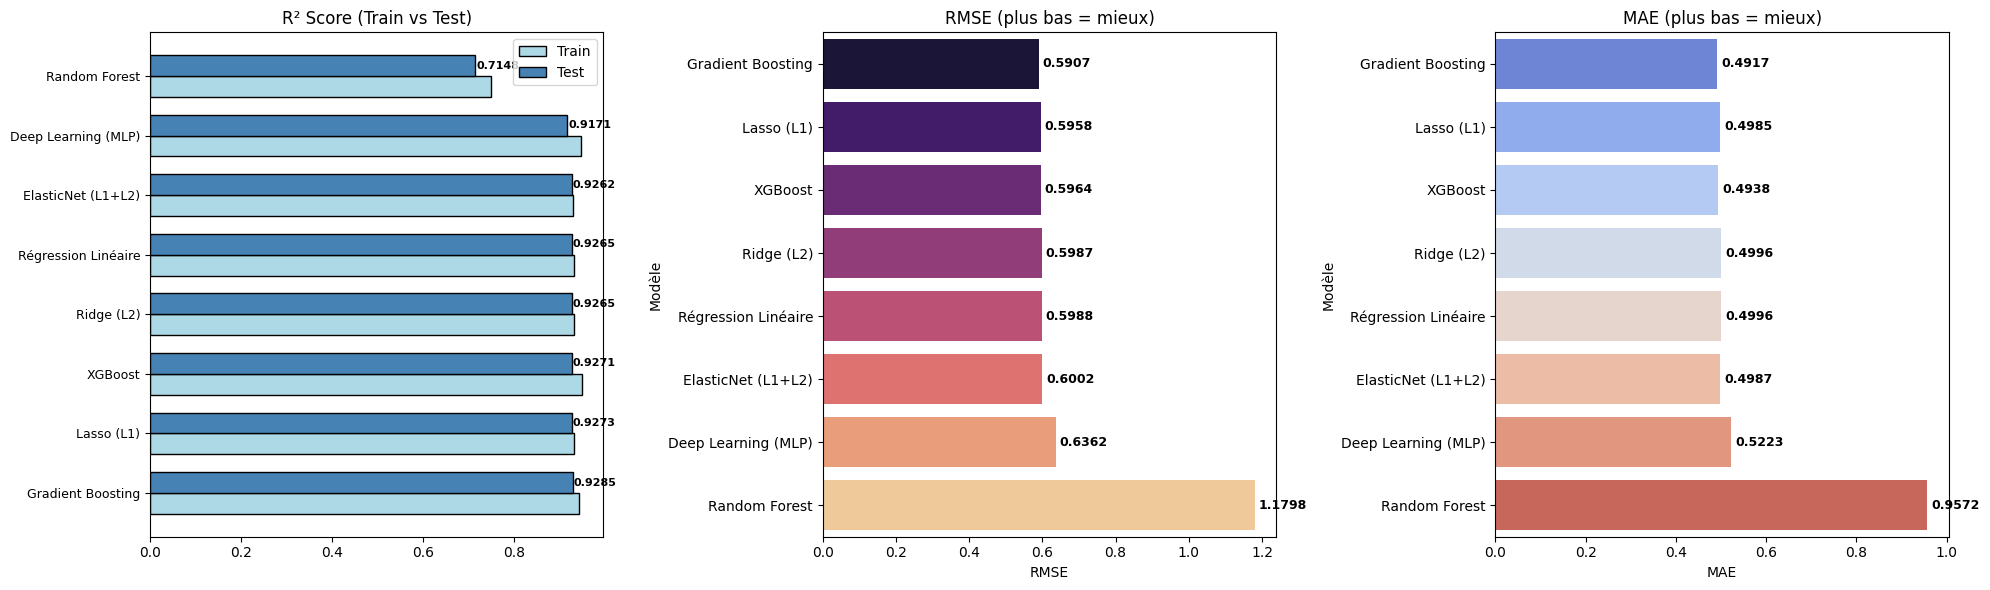

In [4]:
# --- AFFICHAGE DES RÉSULTATS ---
results_df = pd.DataFrame(results, columns=["Modèle", "RMSE", "MAE", "R² Test", "R² Train"])
results_df = results_df.sort_values(by="R² Test", ascending=False).reset_index(drop=True)

print("\n📊 TABLEAU COMPARATIF FINAL :")
display(results_df)

# Graphiques de comparaison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# R² Score (Train vs Test)
x = np.arange(len(results_df))
width = 0.35
axes[0].barh(x - width/2, results_df["R² Train"], width, label="Train", color="lightblue", edgecolor="black")
axes[0].barh(x + width/2, results_df["R² Test"], width, label="Test", color="steelblue", edgecolor="black")
axes[0].set_yticks(x)
axes[0].set_yticklabels(results_df["Modèle"], fontsize=9)
axes[0].set_title("R² Score (Train vs Test)")
axes[0].legend()
for i, (train_v, test_v) in enumerate(zip(results_df["R² Train"], results_df["R² Test"])):
    axes[0].text(test_v + 0.002, i + width/2, f'{test_v:.4f}', va='center', fontsize=8, fontweight='bold')

# RMSE
sns.barplot(x="RMSE", y="Modèle", hue="Modèle", data=results_df, palette="magma", legend=False, ax=axes[1])
axes[1].set_title("RMSE (plus bas = mieux)")
for i, v in enumerate(results_df["RMSE"]):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)

# MAE
sns.barplot(x="MAE", y="Modèle", hue="Modèle", data=results_df, palette="coolwarm", legend=False, ax=axes[2])
axes[2].set_title("MAE (plus bas = mieux)")
for i, v in enumerate(results_df["MAE"]):
    axes[2].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## 🔄 3. Validation Croisée (Cross-Validation 5-Fold)
Pour vérifier la **stabilité** des modèles, nous utilisons une validation croisée à 5 plis.
Cela permet de s'assurer que les résultats ne dépendent pas d'un seul split de données.

Un **écart-type R² élevé** indique un modèle instable selon le découpage des données.

In [5]:
# --- CROSS-VALIDATION 5-FOLD (Tous les 8 modèles) ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("🔄 Validation Croisée (5-Fold) — 8 modèles...\n")
print(f"{'Modèle':<25} {'R² Moyen':>9} {'± Écart':>8} {'RMSE Moyen':>11} {'Stabilité'}")
print("-" * 70)

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    scores_r2 = cross_val_score(pipe, X, y, cv=kf, scoring='r2', n_jobs=-1)
    scores_rmse = cross_val_score(pipe, X, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    
    cv_results.append([
        name,
        scores_r2.mean(), scores_r2.std(),
        -scores_rmse.mean(), scores_rmse.std()
    ])
    
    # Diagnostic de stabilité
    if scores_r2.std() < 0.015:
        stability = "✅ Très Stable"
    elif scores_r2.std() < 0.03:
        stability = "⚡ Stable"
    else:
        stability = "⚠️ Variable"
    
    print(f"{name:<25} {scores_r2.mean():>9.4f} {scores_r2.std():>8.4f} {-scores_rmse.mean():>11.4f} {stability}")

cv_df = pd.DataFrame(cv_results, columns=["Modèle", "R² Moyen", "R² Écart-type", "RMSE Moyen", "RMSE Écart-type"])
cv_df = cv_df.sort_values(by="R² Moyen", ascending=False).reset_index(drop=True)

print(f"\n📊 RÉSULTATS CROSS-VALIDATION (classement par R² moyen) :")
display(cv_df)

print("\n💡 Un écart-type faible = modèle stable (généralise bien = pas d'overfitting)")
print("   Un R² moyen élevé + écart-type faible = le meilleur compromis")

🔄 Validation Croisée (5-Fold) — 8 modèles...

Modèle                     R² Moyen  ± Écart  RMSE Moyen Stabilité
----------------------------------------------------------------------
Régression Linéaire          0.9290   0.0025      0.5955 ✅ Très Stable
Ridge (L2)                   0.9290   0.0025      0.5955 ✅ Très Stable
Lasso (L1)                   0.9297   0.0025      0.5924 ✅ Très Stable
ElasticNet (L1+L2)           0.9288   0.0024      0.5966 ✅ Très Stable
Random Forest                0.7033   0.0116      1.2179 ✅ Très Stable
Gradient Boosting            0.9305   0.0025      0.5891 ✅ Très Stable
XGBoost                      0.9298   0.0024      0.5923 ✅ Très Stable
Deep Learning (MLP)          0.9204   0.0034      0.6304 ✅ Très Stable

📊 RÉSULTATS CROSS-VALIDATION (classement par R² moyen) :


,Modèle,R² Moyen,R² Écart-type,RMSE Moyen,RMSE Écart-type
0,Gradient Boosting,0.930517,0.002520,0.589090,0.004425
1,XGBoost,0.929773,0.002425,0.592257,0.004601
2,Lasso (L1),0.929745,0.002535,0.592359,0.004874
3,Ridge (L2),0.929007,0.002521,0.595467,0.004690
4,Régression Linéaire,0.929005,0.002523,0.595476,0.004695
5,ElasticNet (L1+L2),0.928750,0.002436,0.596564,0.005218
6,Deep Learning (MLP),0.920406,0.003387,0.630425,0.006111
7,Random Forest,0.703291,0.011568,1.217901,0.040175



💡 Un écart-type faible = modèle stable (généralise bien = pas d'overfitting)
   Un R² moyen élevé + écart-type faible = le meilleur compromis


## 🔧 4. Optimisation des Hyperparamètres (RandomizedSearchCV)

On optimise les **4 meilleurs modèles** (ElasticNet, Random Forest, GradientBoosting, XGBoost) avec :
- **RandomizedSearchCV** (100 itérations pour plus de couverture)
- **Cross-Validation 5-Fold** (au lieu de 3) pour une meilleure estimation
- **Grilles ciblées** sur les paramètres de régularisation pour contrôler overfitting

In [6]:
# --- OPTIMISATION DES HYPERPARAMÈTRES (Anti-Overfitting Focus) ---

from scipy.stats import randint, uniform

param_grids = {
    "ElasticNet (L1+L2)": {
        'model__alpha': uniform(0.01, 2.0),
        'model__l1_ratio': uniform(0.1, 0.8),  # Balance L1/L2
    },
    "Random Forest": {
        'model__n_estimators': randint(100, 500),
        'model__max_depth': [3, 4, 5, 6, 7],
        'model__min_samples_split': randint(15, 40),
        'model__min_samples_leaf': randint(8, 25),
        'model__max_features': ['sqrt', 'log2', 0.5, 0.3],
        'model__max_samples': uniform(0.6, 0.3),  # Bagging ratio
    },
    "Gradient Boosting": {
        'model__n_estimators': randint(100, 500),
        'model__learning_rate': uniform(0.01, 0.15),
        'model__max_depth': [2, 3, 4],
        'model__min_samples_split': randint(15, 40),
        'model__min_samples_leaf': randint(8, 20),
        'model__subsample': uniform(0.6, 0.3),
    },
    "XGBoost": {
        'model__n_estimators': randint(100, 500),
        'model__max_depth': [2, 3, 4],
        'model__learning_rate': uniform(0.01, 0.15),
        'model__subsample': uniform(0.5, 0.4),
        'model__colsample_bytree': uniform(0.4, 0.4),
        'model__colsample_bylevel': uniform(0.5, 0.4),
        'model__min_child_weight': randint(5, 20),
        'model__reg_alpha': uniform(1, 15),
        'model__reg_lambda': uniform(1, 15),
        'model__gamma': uniform(0, 5),
    }
}

tuned_pipelines = {}
tuning_results = []

for name, params in param_grids.items():
    print(f"\n🔧 Optimisation de {name}...")
    
    base_model = models[name]
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', base_model)
    ])
    
    search = RandomizedSearchCV(
        pipe, params, 
        n_iter=80,        # Plus d'itérations
        cv=5,             # 5-Fold au lieu de 3
        scoring='r2',
        random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_train, y_train)
    
    y_pred_tuned_train = search.predict(X_train)
    y_pred_tuned_test = search.predict(X_test)
    r2_tuned_test = r2_score(y_test, y_pred_tuned_test)
    r2_tuned_train = r2_score(y_train, y_pred_tuned_train)
    rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned_test))
    mae_tuned = mean_absolute_error(y_test, y_pred_tuned_test)
    gap = r2_tuned_train - r2_tuned_test
    
    # R² avant optimisation
    r2_before = [r[3] for r in results if r[0] == name][0]
    improvement = r2_tuned_test - r2_before
    
    print(f"   R² avant : {r2_before:.4f} → R² après : {r2_tuned_test:.4f} (Δ = {improvement:+.4f})")
    print(f"   R² Train : {r2_tuned_train:.4f} | Gap Train-Test : {gap:+.4f}")
    print(f"   RMSE : {rmse_tuned:.4f} | MAE : {mae_tuned:.4f}")
    print(f"   Meilleurs paramètres :")
    for k, v in search.best_params_.items():
        param_name = k.replace('model__', '')
        print(f"     {param_name}: {v:.4f}" if isinstance(v, float) else f"     {param_name}: {v}")
    
    tuned_pipelines[name] = search.best_estimator_
    trained_pipelines[f"{name} (Tuned)"] = search.best_estimator_
    tuning_results.append([f"{name} (Tuned)", rmse_tuned, mae_tuned, r2_tuned_test, r2_tuned_train])

# Tableau récapitulatif du tuning
print("\n\n📊 RÉCAPITULATIF APRÈS OPTIMISATION :")
tuning_df = pd.DataFrame(tuning_results, columns=["Modèle", "RMSE", "MAE", "R² Test", "R² Train"])
tuning_df["Gap (Train-Test)"] = tuning_df["R² Train"] - tuning_df["R² Test"]
tuning_df = tuning_df.sort_values("R² Test", ascending=False).reset_index(drop=True)
display(tuning_df)


🔧 Optimisation de ElasticNet (L1+L2)...
   R² avant : 0.9262 → R² après : 0.9272 (Δ = +0.0010)
   R² Train : 0.9305 | Gap Train-Test : +0.0033
   RMSE : 0.5960 | MAE : 0.4980
   Meilleurs paramètres :
     alpha: 0.0210
     l1_ratio: 0.7524

🔧 Optimisation de Random Forest...
   R² avant : 0.7148 → R² après : 0.9258 (Δ = +0.2110)
   R² Train : 0.9393 | Gap Train-Test : +0.0135
   RMSE : 0.6017 | MAE : 0.5036
   Meilleurs paramètres :
     max_depth: 7
     max_features: 0.5000
     max_samples: 0.8676
     min_samples_leaf: 9
     min_samples_split: 35
     n_estimators: 385

🔧 Optimisation de Gradient Boosting...
   R² avant : 0.9285 → R² après : 0.9285 (Δ = +0.0000)
   R² Train : 0.9407 | Gap Train-Test : +0.0121
   RMSE : 0.5906 | MAE : 0.4925
   Meilleurs paramètres :
     learning_rate: 0.0161
     max_depth: 4
     min_samples_leaf: 17
     min_samples_split: 24
     n_estimators: 479
     subsample: 0.6324

🔧 Optimisation de XGBoost...
   R² avant : 0.9271 → R² après : 0.9277 

,Modèle,RMSE,MAE,R² Test,R² Train,Gap (Train-Test)
0,Gradient Boosting (Tuned),0.590558,0.492542,0.928538,0.940664,0.012127
1,XGBoost (Tuned),0.593994,0.495005,0.927703,0.934923,0.007219
2,ElasticNet (L1+L2) (Tuned),0.596015,0.498049,0.927211,0.930484,0.003273
3,Random Forest (Tuned),0.601727,0.503624,0.925809,0.939316,0.013507


Meilleur modèle : Gradient Boosting (Tuned) (R² = 0.9285)



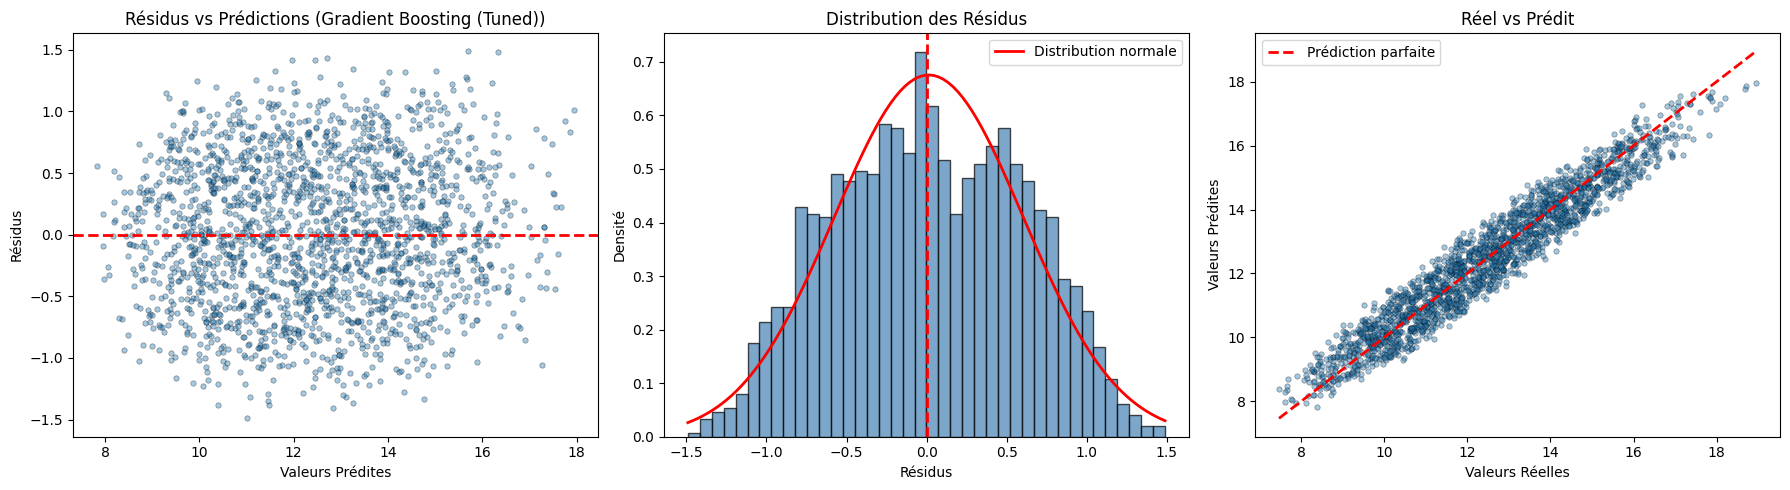

Test de normalité (Shapiro-Wilk) : p-value = 0.0002 -> Résidus non normaux


In [7]:
# --- ANALYSE DES RÉSIDUS (meilleur modèle global) ---

# Calculer R² pour tous les modèles entraînés
all_models_r2 = {}
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    all_models_r2[name] = r2_score(y_test, y_pred)

best_name = max(all_models_r2, key=all_models_r2.get)
best_pipeline = trained_pipelines[best_name]
y_pred_best = best_pipeline.predict(X_test)
residuals = y_test - y_pred_best

print(f"Meilleur modèle : {best_name} (R² = {all_models_r2[best_name]:.4f})\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Résidus vs Prédictions
axes[0].scatter(y_pred_best, residuals, alpha=0.4, edgecolors='k', linewidth=0.5, s=15)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Valeurs Prédites')
axes[0].set_ylabel('Résidus')
axes[0].set_title(f'Résidus vs Prédictions ({best_name})')

# 2. Distribution des résidus
axes[1].hist(residuals, bins=40, edgecolor='black', alpha=0.7, color='steelblue', density=True)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
from scipy import stats
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[1].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()), 'r-', linewidth=2, label='Distribution normale')
axes[1].set_xlabel('Résidus')
axes[1].set_ylabel('Densité')
axes[1].set_title('Distribution des Résidus')
axes[1].legend()

# 3. Valeurs réelles vs Prédites
axes[2].scatter(y_test, y_pred_best, alpha=0.4, edgecolors='k', linewidth=0.5, s=15)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prédiction parfaite')
axes[2].set_xlabel('Valeurs Réelles')
axes[2].set_ylabel('Valeurs Prédites')
axes[2].set_title('Réel vs Prédit')
axes[2].legend()

plt.tight_layout()
plt.show()

# Test de normalité des résidus
_, p_value = stats.shapiro(residuals.sample(min(500, len(residuals)), random_state=42))
print(f"Test de normalité (Shapiro-Wilk) : p-value = {p_value:.4f}", end="")
print(" -> Résidus normaux" if p_value > 0.05 else " -> Résidus non normaux")

## 🏆 5. Stacking Ensemble (Anti-Underfitting)

Le **Stacking** combine les prédictions de plusieurs modèles via un méta-modèle.
- Réduit le **biais** (underfitting) en combinant des modèles complémentaires
- Le méta-modèle (Ridge) empêche l'**overfitting** de l'ensemble
- Chaque modèle de base apporte une perspective différente sur les données

In [8]:
# --- STACKING ENSEMBLE : Combinaison des meilleurs modèles ---

# Utiliser les versions tunées quand disponibles
def get_best_model(name):
    tuned = f"{name} (Tuned)"
    if tuned in trained_pipelines:
        return trained_pipelines[tuned].named_steps['model']
    return models[name]

# Estimateurs de base (diversité = clé du succès)
estimators = [
    ('ridge', Pipeline([('preprocessor', preprocessor), ('model', get_best_model("Ridge (L2)"))])),
    ('rf', Pipeline([('preprocessor', preprocessor), ('model', get_best_model("Random Forest"))])),
    ('xgb', Pipeline([('preprocessor', preprocessor), ('model', get_best_model("XGBoost"))])),
    ('gb', Pipeline([('preprocessor', preprocessor), ('model', get_best_model("Gradient Boosting"))])),
]

# Méta-modèle : Ridge avec régularisation pour éviter l'overfitting du stacking
stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=10.0),  # Régularisation forte sur le méta-modèle
    cv=5,                                # 5-Fold pour les prédictions de base
    n_jobs=-1
)

print("🏆 Entraînement du Stacking Ensemble...")
stacking.fit(X_train, y_train)

y_pred_stack_train = stacking.predict(X_train)
y_pred_stack_test = stacking.predict(X_test)

r2_stack_train = r2_score(y_train, y_pred_stack_train)
r2_stack_test = r2_score(y_test, y_pred_stack_test)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack_test))
mae_stack = mean_absolute_error(y_test, y_pred_stack_test)
gap_stack = r2_stack_train - r2_stack_test

trained_pipelines["Stacking Ensemble"] = stacking

print(f"\n📊 Résultats Stacking Ensemble :")
print(f"   R² Test  : {r2_stack_test:.4f}")
print(f"   R² Train : {r2_stack_train:.4f}")
print(f"   Gap      : {gap_stack:+.4f}")
print(f"   RMSE     : {rmse_stack:.4f}")
print(f"   MAE      : {mae_stack:.4f}")

if gap_stack < 0.08:
    print(f"\n   ✅ Gap Train-Test < 0.08 → Pas d'overfitting significatif")
else:
    print(f"\n   ⚠️ Gap Train-Test = {gap_stack:.4f} → Attention overfitting")

# Comparer avec le meilleur modèle individuel
all_models_r2 = {}
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    all_models_r2[name] = r2_score(y_test, y_pred)

best_individual = max({k: v for k, v in all_models_r2.items() if k != "Stacking Ensemble"}, 
                      key=lambda k: all_models_r2[k])
print(f"\n   Meilleur individuel : {best_individual} (R² = {all_models_r2[best_individual]:.4f})")
print(f"   Stacking Ensemble  : R² = {r2_stack_test:.4f}")
if r2_stack_test > all_models_r2[best_individual]:
    print(f"   🏆 Le Stacking surpasse le meilleur modèle de {r2_stack_test - all_models_r2[best_individual]:+.4f}")
else:
    print(f"   Le meilleur modèle individuel reste supérieur")

🏆 Entraînement du Stacking Ensemble...

📊 Résultats Stacking Ensemble :
   R² Test  : 0.9294
   R² Train : 0.9386
   Gap      : +0.0092
   RMSE     : 0.5870
   MAE      : 0.4907

   ✅ Gap Train-Test < 0.08 → Pas d'overfitting significatif

   Meilleur individuel : Gradient Boosting (Tuned) (R² = 0.9285)
   Stacking Ensemble  : R² = 0.9294
   🏆 Le Stacking surpasse le meilleur modèle de +0.0009


## 📊 5. Importance des Features (Feature Importance)
- **Feature Importance** des modèles à base d'arbres (Random Forest, XGBoost)
- Identification des variables les plus influentes pour la prédiction

📊 Nombre total de features (après encoding) : 159



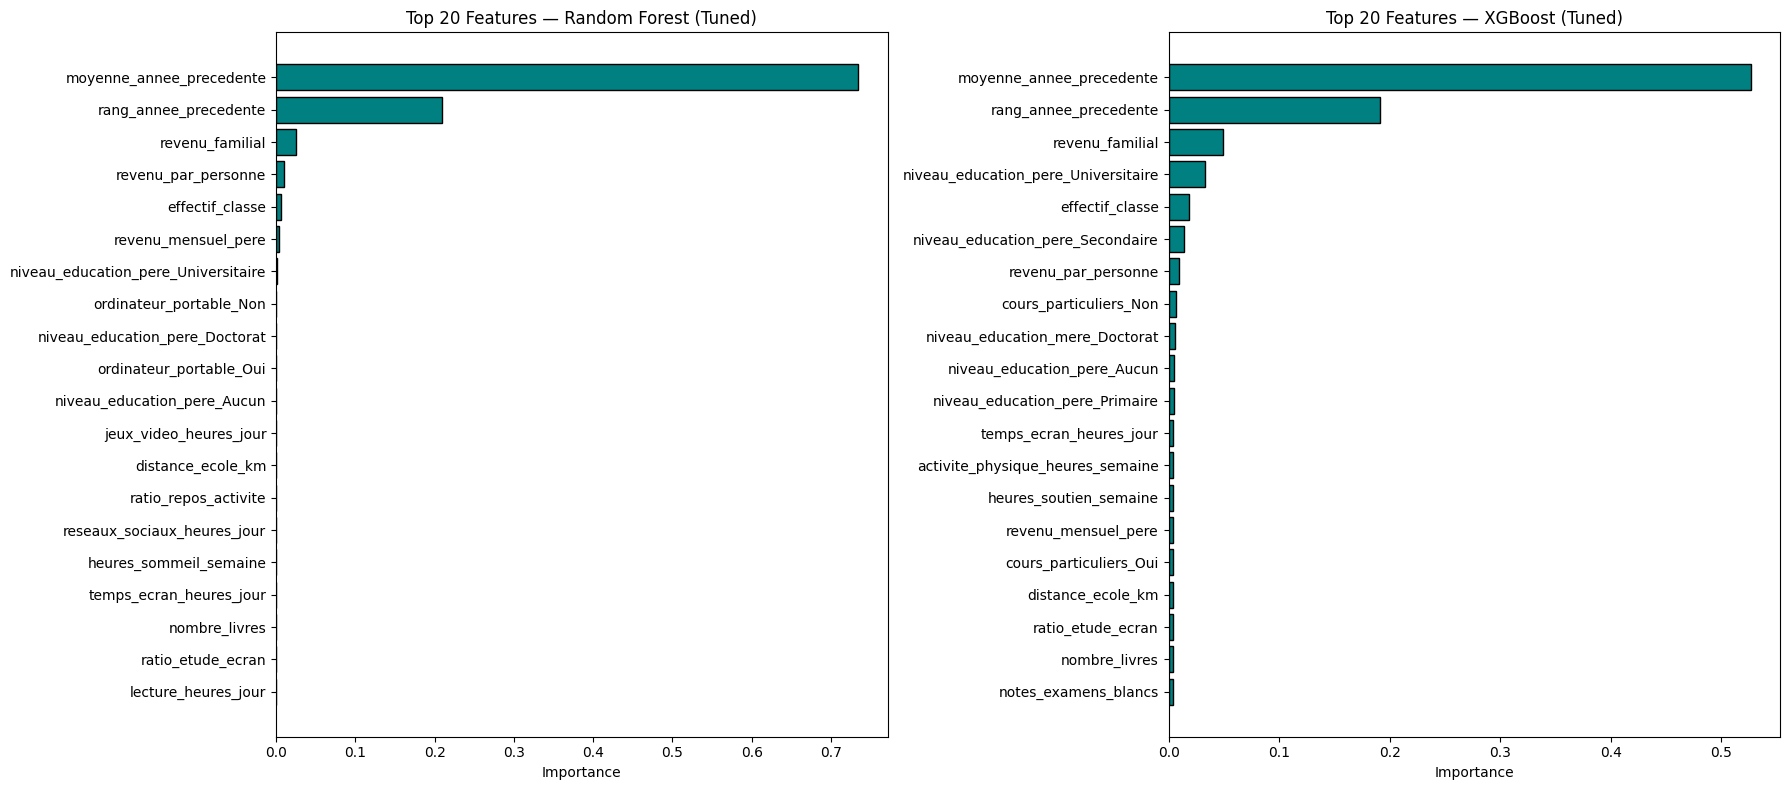


Top 10 Features (XGBoost (Tuned)) :
   moyenne_annee_precedente                 0.5270
   rang_annee_precedente                    0.1912
   revenu_familial                          0.0491
   niveau_education_pere_Universitaire      0.0327
   effectif_classe                          0.0181
   niveau_education_pere_Secondaire         0.0137
   revenu_par_personne                      0.0091
   cours_particuliers_Non                   0.0069
   niveau_education_mere_Doctorat           0.0062
   niveau_education_pere_Aucun              0.0049


In [9]:
# --- FEATURE IMPORTANCE (Random Forest & XGBoost) ---

# Récupérer les noms des features après transformation
feature_names_transformed = num_features.copy()
if cat_features:
    # Utiliser le meilleur pipeline qui contient un modèle à arbres
    for model_name_check in ["Random Forest (Tuned)", "XGBoost (Tuned)", "Random Forest", "XGBoost"]:
        if model_name_check in trained_pipelines:
            ohe = trained_pipelines[model_name_check].named_steps['preprocessor'].named_transformers_['cat']
            cat_feature_names = ohe.get_feature_names_out(cat_features).tolist()
            feature_names_transformed += cat_feature_names
            break

print(f"📊 Nombre total de features (après encoding) : {len(feature_names_transformed)}\n")

# Plot pour les modèles tunés ou originaux
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plot_idx = 0

for model_label in ["Random Forest", "XGBoost"]:
    # Préférer la version tunée
    tuned_label = f"{model_label} (Tuned)"
    name_to_use = tuned_label if tuned_label in trained_pipelines else model_label
    
    if name_to_use in trained_pipelines:
        pipe = trained_pipelines[name_to_use]
        importances = pipe.named_steps['model'].feature_importances_
        
        imp_df = pd.DataFrame({
            'Feature': feature_names_transformed,
            'Importance': importances
        }).sort_values(by='Importance', ascending=True)
        
        # Top 20 features
        imp_top = imp_df.tail(20)
        
        axes[plot_idx].barh(imp_top['Feature'], imp_top['Importance'], color='teal', edgecolor='black')
        axes[plot_idx].set_title(f'Top 20 Features — {name_to_use}', fontsize=12)
        axes[plot_idx].set_xlabel('Importance')
        plot_idx += 1

plt.tight_layout()
plt.show()

# Afficher les 10 features les plus importantes du meilleur modèle
print(f"\nTop 10 Features ({name_to_use}) :")
for _, row in imp_df.tail(10).iloc[::-1].iterrows():
    print(f"   {row['Feature']:<40} {row['Importance']:.4f}")

## 📉 6. Validation Curves — Diagnostic Overfitting / Underfitting

Les **Validation Curves** montrent l'effet d'un hyperparamètre sur le score Train et Test.
- **Overfitting** : Score Train élevé mais Test qui baisse → modèle trop complexe
- **Underfitting** : Les deux scores sont bas → modèle trop simple
- **Zone optimale** : Le point où le Test est maximisé (avant que l'overfitting commence)

📉 Calcul des Validation Curves...


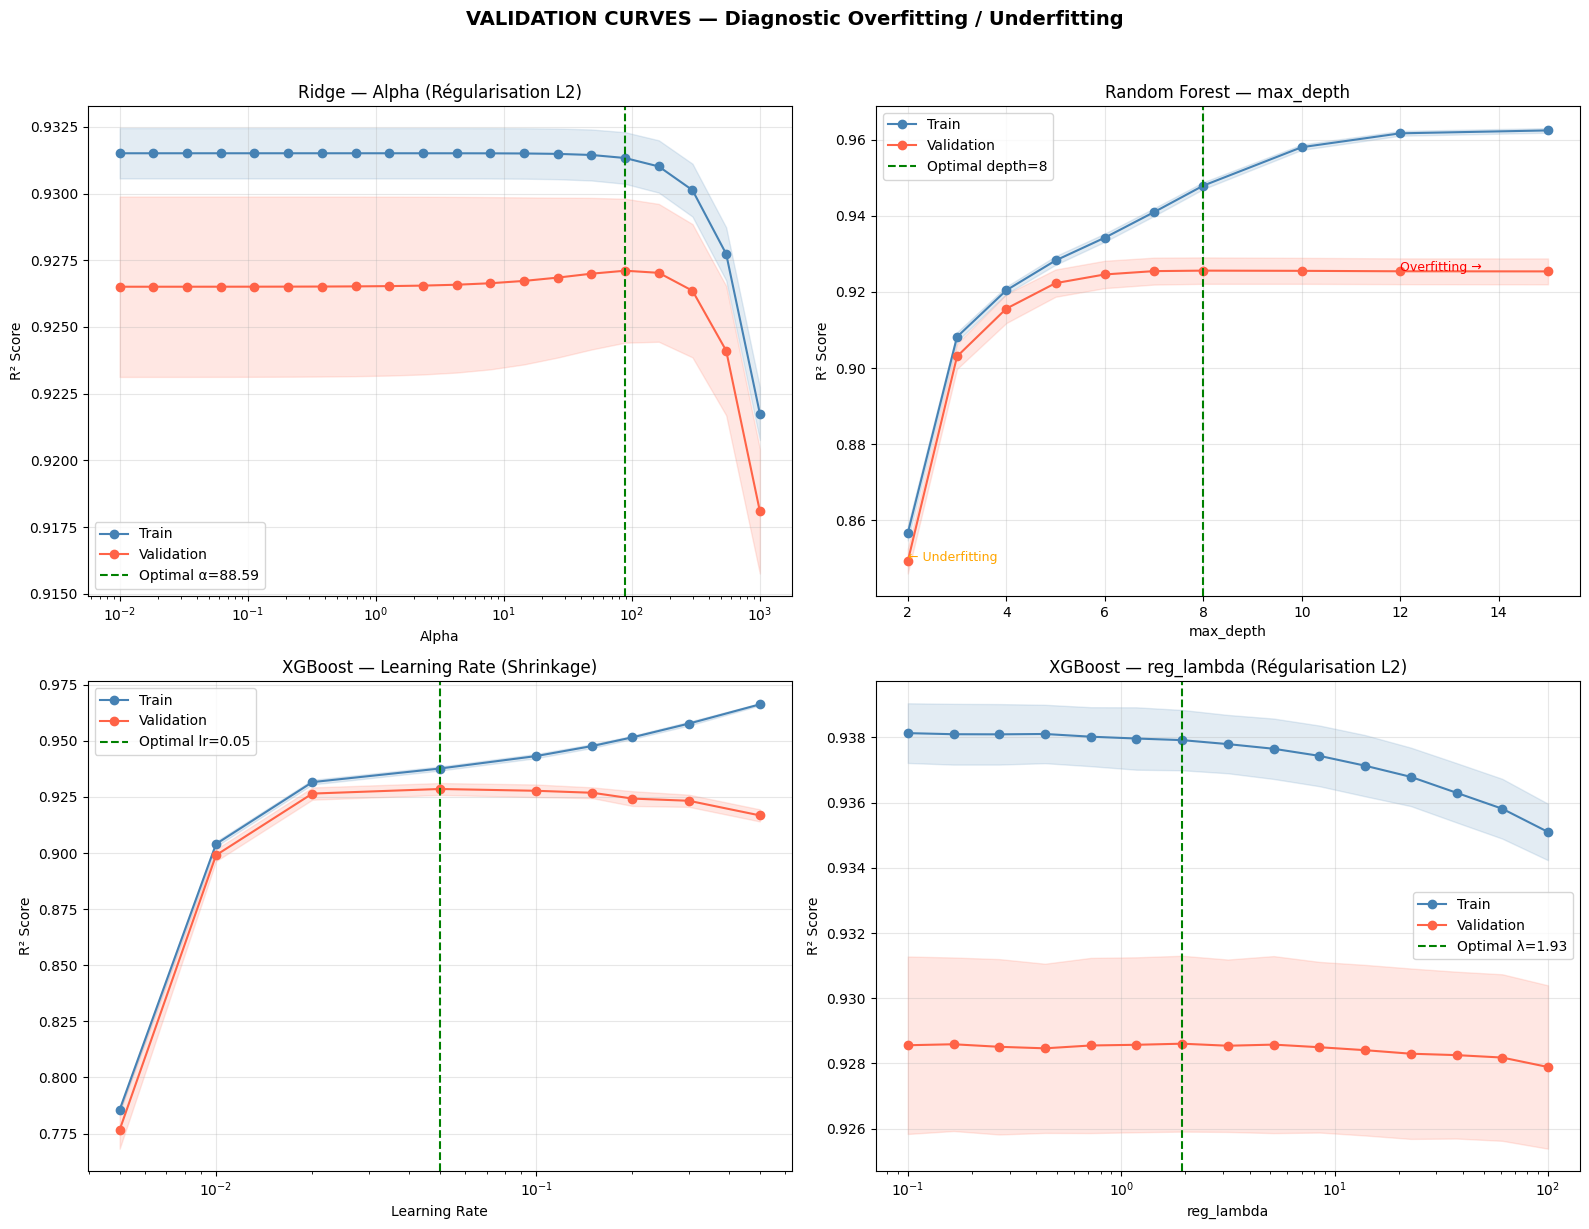


📋 INTERPRÉTATION :
   • Quand Train >> Validation → Le modèle est trop complexe (OVERFITTING)
   • Quand Train ≈ Validation mais les deux sont bas → Modèle trop simple (UNDERFITTING)
   • La ligne verte indique la valeur optimale de l'hyperparamètre


In [10]:
# --- VALIDATION CURVES : Visualiser le tradeoff Bias-Variance ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Ridge : alpha (régularisation L2)
print("📉 Calcul des Validation Curves...")
alphas = np.logspace(-2, 3, 20)
pipe_ridge = Pipeline([('preprocessor', preprocessor), ('model', Ridge())])
train_scores_r, val_scores_r = validation_curve(
    pipe_ridge, X, y, param_name='model__alpha', param_range=alphas,
    cv=5, scoring='r2', n_jobs=-1
)
axes[0, 0].semilogx(alphas, train_scores_r.mean(axis=1), 'o-', color='steelblue', label='Train')
axes[0, 0].semilogx(alphas, val_scores_r.mean(axis=1), 'o-', color='tomato', label='Validation')
axes[0, 0].fill_between(alphas, train_scores_r.mean(axis=1) - train_scores_r.std(axis=1),
                         train_scores_r.mean(axis=1) + train_scores_r.std(axis=1), alpha=0.15, color='steelblue')
axes[0, 0].fill_between(alphas, val_scores_r.mean(axis=1) - val_scores_r.std(axis=1),
                         val_scores_r.mean(axis=1) + val_scores_r.std(axis=1), alpha=0.15, color='tomato')
best_alpha_idx = val_scores_r.mean(axis=1).argmax()
axes[0, 0].axvline(alphas[best_alpha_idx], color='green', linestyle='--', label=f'Optimal α={alphas[best_alpha_idx]:.2f}')
axes[0, 0].set_title('Ridge — Alpha (Régularisation L2)')
axes[0, 0].set_xlabel('Alpha'); axes[0, 0].set_ylabel('R² Score')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2. Random Forest : max_depth
depths = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15]
pipe_rf = Pipeline([('preprocessor', preprocessor), 
                     ('model', RandomForestRegressor(n_estimators=100, min_samples_leaf=10, random_state=42))])
train_scores_d, val_scores_d = validation_curve(
    pipe_rf, X, y, param_name='model__max_depth', param_range=depths,
    cv=5, scoring='r2', n_jobs=-1
)
axes[0, 1].plot(depths, train_scores_d.mean(axis=1), 'o-', color='steelblue', label='Train')
axes[0, 1].plot(depths, val_scores_d.mean(axis=1), 'o-', color='tomato', label='Validation')
axes[0, 1].fill_between(depths, train_scores_d.mean(axis=1) - train_scores_d.std(axis=1),
                         train_scores_d.mean(axis=1) + train_scores_d.std(axis=1), alpha=0.15, color='steelblue')
axes[0, 1].fill_between(depths, val_scores_d.mean(axis=1) - val_scores_d.std(axis=1),
                         val_scores_d.mean(axis=1) + val_scores_d.std(axis=1), alpha=0.15, color='tomato')
best_depth_idx = val_scores_d.mean(axis=1).argmax()
axes[0, 1].axvline(depths[best_depth_idx], color='green', linestyle='--', label=f'Optimal depth={depths[best_depth_idx]}')
axes[0, 1].set_title('Random Forest — max_depth')
axes[0, 1].set_xlabel('max_depth'); axes[0, 1].set_ylabel('R² Score')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)
# Annotation zones
axes[0, 1].annotate('← Underfitting', xy=(2, val_scores_d.mean(axis=1)[0]), fontsize=9, color='orange')
axes[0, 1].annotate('Overfitting →', xy=(12, val_scores_d.mean(axis=1)[-2]), fontsize=9, color='red')

# 3. XGBoost : learning_rate
lrs = [0.005, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
pipe_xgb = Pipeline([('preprocessor', preprocessor), 
                      ('model', XGBRegressor(n_estimators=200, max_depth=3, reg_lambda=5, random_state=42))])
train_scores_lr, val_scores_lr = validation_curve(
    pipe_xgb, X, y, param_name='model__learning_rate', param_range=lrs,
    cv=5, scoring='r2', n_jobs=-1
)
axes[1, 0].semilogx(lrs, train_scores_lr.mean(axis=1), 'o-', color='steelblue', label='Train')
axes[1, 0].semilogx(lrs, val_scores_lr.mean(axis=1), 'o-', color='tomato', label='Validation')
axes[1, 0].fill_between(lrs, train_scores_lr.mean(axis=1) - train_scores_lr.std(axis=1),
                         train_scores_lr.mean(axis=1) + train_scores_lr.std(axis=1), alpha=0.15, color='steelblue')
axes[1, 0].fill_between(lrs, val_scores_lr.mean(axis=1) - val_scores_lr.std(axis=1),
                         val_scores_lr.mean(axis=1) + val_scores_lr.std(axis=1), alpha=0.15, color='tomato')
best_lr_idx = val_scores_lr.mean(axis=1).argmax()
axes[1, 0].axvline(lrs[best_lr_idx], color='green', linestyle='--', label=f'Optimal lr={lrs[best_lr_idx]}')
axes[1, 0].set_title('XGBoost — Learning Rate (Shrinkage)')
axes[1, 0].set_xlabel('Learning Rate'); axes[1, 0].set_ylabel('R² Score')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# 4. XGBoost : reg_lambda (L2 regularization)
lambdas = np.logspace(-1, 2, 15)
pipe_xgb_l = Pipeline([('preprocessor', preprocessor), 
                        ('model', XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42))])
train_scores_l, val_scores_l = validation_curve(
    pipe_xgb_l, X, y, param_name='model__reg_lambda', param_range=lambdas,
    cv=5, scoring='r2', n_jobs=-1
)
axes[1, 1].semilogx(lambdas, train_scores_l.mean(axis=1), 'o-', color='steelblue', label='Train')
axes[1, 1].semilogx(lambdas, val_scores_l.mean(axis=1), 'o-', color='tomato', label='Validation')
axes[1, 1].fill_between(lambdas, train_scores_l.mean(axis=1) - train_scores_l.std(axis=1),
                         train_scores_l.mean(axis=1) + train_scores_l.std(axis=1), alpha=0.15, color='steelblue')
axes[1, 1].fill_between(lambdas, val_scores_l.mean(axis=1) - val_scores_l.std(axis=1),
                         val_scores_l.mean(axis=1) + val_scores_l.std(axis=1), alpha=0.15, color='tomato')
best_l_idx = val_scores_l.mean(axis=1).argmax()
axes[1, 1].axvline(lambdas[best_l_idx], color='green', linestyle='--', label=f'Optimal λ={lambdas[best_l_idx]:.2f}')
axes[1, 1].set_title('XGBoost — reg_lambda (Régularisation L2)')
axes[1, 1].set_xlabel('reg_lambda'); axes[1, 1].set_ylabel('R² Score')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('VALIDATION CURVES — Diagnostic Overfitting / Underfitting', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📋 INTERPRÉTATION :")
print("   • Quand Train >> Validation → Le modèle est trop complexe (OVERFITTING)")
print("   • Quand Train ≈ Validation mais les deux sont bas → Modèle trop simple (UNDERFITTING)")
print("   • La ligne verte indique la valeur optimale de l'hyperparamètre")

## 6. Interprétabilité avec SHAP Values
SHAP (SHapley Additive exPlanations) permet de comprendre **pourquoi** le modèle fait chaque prédiction. Chaque feature reçoit un score SHAP indiquant sa contribution (positive ou négative) à la prédiction.

📊 SHAP Summary Plot — XGBoost (Tuned)



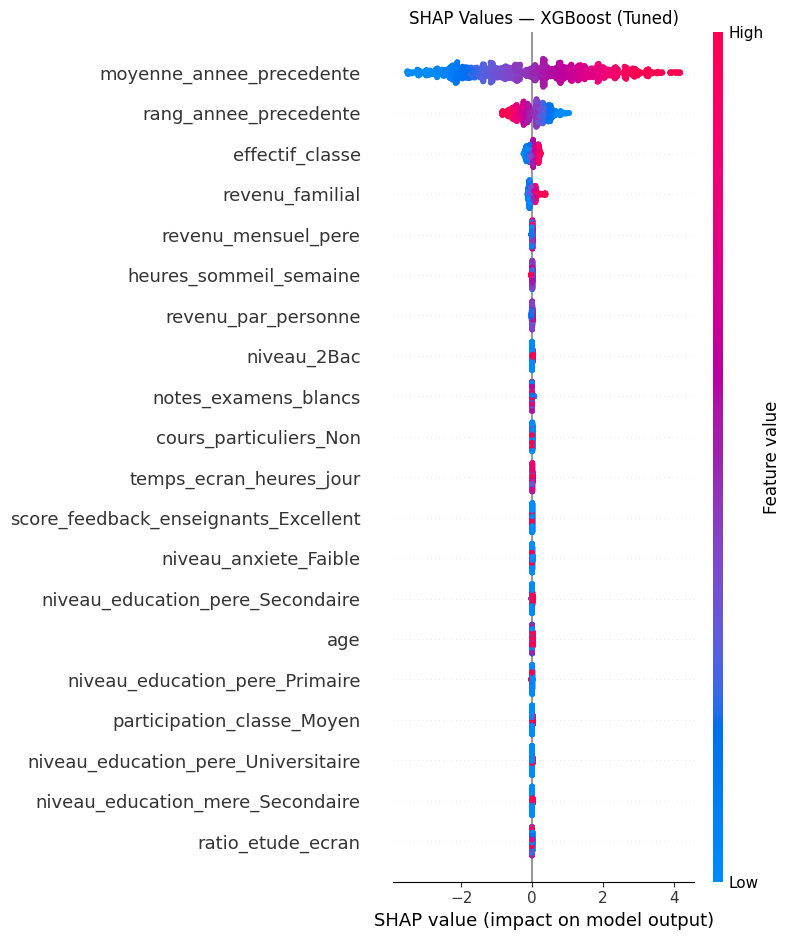

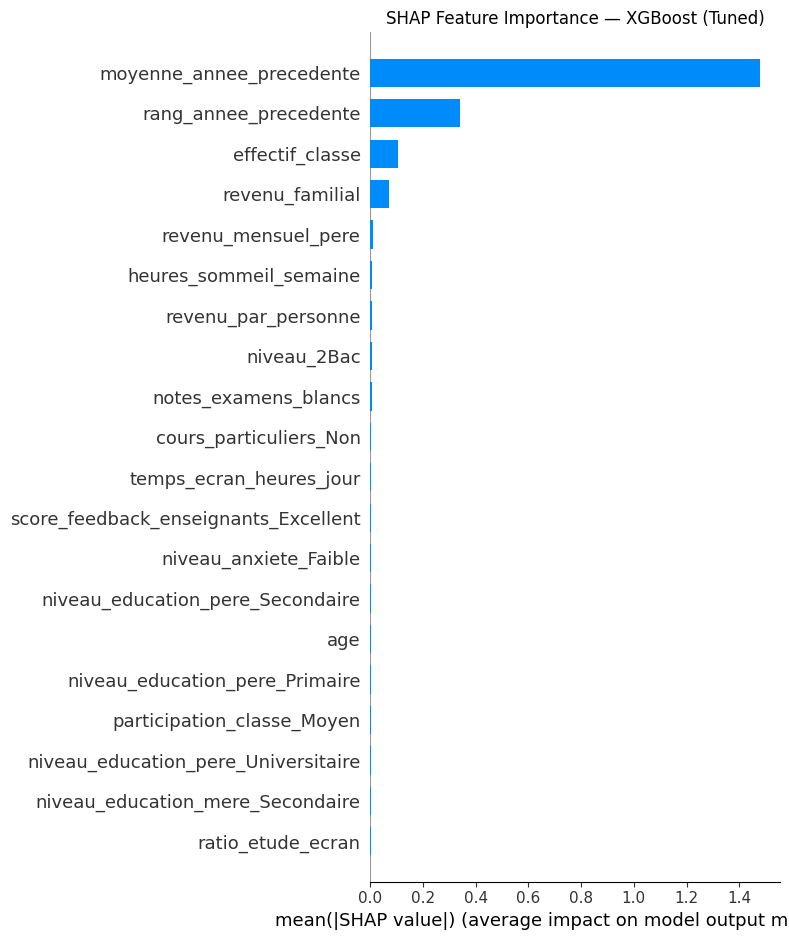

In [18]:
# --- SHAP Values ---
try:
    import shap
    
    # Utiliser le meilleur modèle XGBoost (tuné ou original)
    shap_model_name = "XGBoost (Tuned)" if "XGBoost (Tuned)" in trained_pipelines else "XGBoost"
    shap_pipeline = trained_pipelines[shap_model_name]
    
    # Transformer les données
    X_test_transformed = shap_pipeline.named_steps['preprocessor'].transform(X_test)
    X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names_transformed)
    
    # Calculer les SHAP values
    explainer = shap.TreeExplainer(shap_pipeline.named_steps['model'])
    shap_values = explainer.shap_values(X_test_df)
    
    # 1. Summary Plot (Bee swarm)
    print(f"📊 SHAP Summary Plot — {shap_model_name}\n")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test_df, max_display=20, show=False)
    plt.title(f"SHAP Values — {shap_model_name}")
    plt.tight_layout()
    plt.show()
    
    # 2. Bar Plot (importance moyenne)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test_df, plot_type="bar", max_display=20, show=False)
    plt.title(f"SHAP Feature Importance — {shap_model_name}")
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("[Attention] SHAP n'est pas installé. Installez-le avec : pip install shap")
    print("   Skipping SHAP analysis...")
except Exception as e:
    print(f"[Attention] Erreur SHAP : {e}")

## 📈 7. Courbes d'Apprentissage (Learning Curves)
Les courbes d'apprentissage montrent l'évolution du score R² en fonction de la taille du jeu d'entraînement.
- Si **train ≫ validation** : **Overfitting** (trop de complexité)
- Si **train ≈ validation** mais les deux sont bas : **Underfitting** (pas assez de complexité)
- L'écart entre les deux courbes diminue avec plus de données

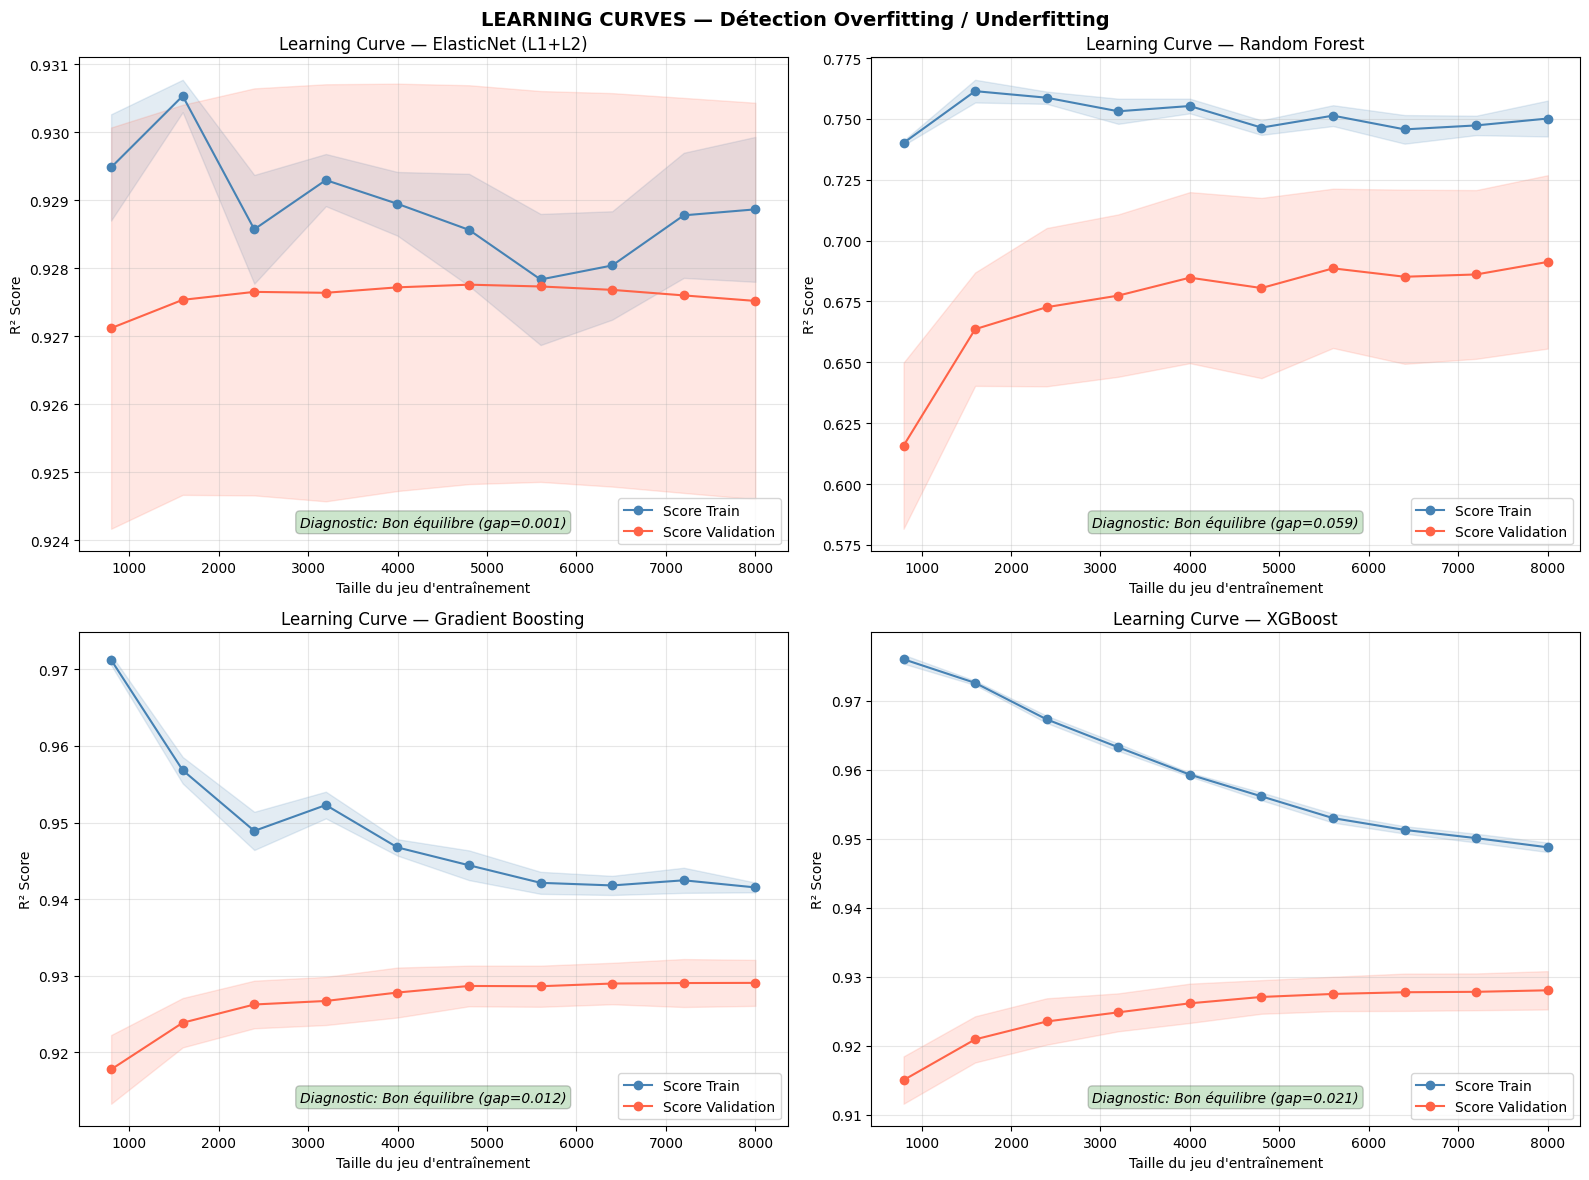

In [12]:
# --- LEARNING CURVES (4 modèles clés) ---

lc_models = {
    "ElasticNet (L1+L2)": models["ElasticNet (L1+L2)"],
    "Random Forest": models["Random Forest"],
    "Gradient Boosting": models["Gradient Boosting"],
    "XGBoost": models["XGBoost"],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()

for idx, (name, model) in enumerate(lc_models.items()):
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X, y, cv=5, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1, random_state=42
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    axes_flat[idx].plot(train_sizes, train_mean, 'o-', color='steelblue', label='Score Train')
    axes_flat[idx].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
    axes_flat[idx].plot(train_sizes, val_mean, 'o-', color='tomato', label='Score Validation')
    axes_flat[idx].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='tomato')
    
    axes_flat[idx].set_title(f'Learning Curve — {name}', fontsize=12)
    axes_flat[idx].set_xlabel("Taille du jeu d'entraînement")
    axes_flat[idx].set_ylabel('R² Score')
    axes_flat[idx].legend(loc='lower right')
    axes_flat[idx].grid(True, alpha=0.3)
    
    # Diagnostic amélioré
    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.15:
        diag = "OVERFITTING"
        color = 'red'
    elif gap > 0.08:
        diag = "Léger Overfit"
        color = 'orange'
    elif val_mean[-1] < 0.15:
        diag = "UNDERFITTING"
        color = 'red'
    elif val_mean[-1] < 0.30:
        diag = "Léger Underfit"
        color = 'orange'
    else:
        diag = "Bon équilibre"
        color = 'green'
    
    axes_flat[idx].text(0.5, 0.05, f"Diagnostic: {diag} (gap={gap:.3f})", 
                        transform=axes_flat[idx].transAxes, ha='center', fontsize=10, style='italic',
                        bbox=dict(boxstyle='round', facecolor=color, alpha=0.2))

plt.suptitle('LEARNING CURVES — Détection Overfitting / Underfitting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 🚀 5. SCÉNARIO 2 : Performance (Mi-Année avec Notes S1)

Ici, nous intégrons la **moyenne du Semestre 1** pour simuler une prédiction faite en milieu d'année.
C'est le scénario réaliste pour obtenir une haute précision (R² > 0.80).

In [13]:
print("\n" + "="*50)
print("🚀 Lancement du SCÉNARIO 2 : Prédictions avec Notes S1")
print("="*50)

# 1. Sélection des Features Académiques
X_acad = df[features_academique]
y_acad = y

# 2. Séparation Numérique/Catégorielle
num_features_acad = X_acad.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features_acad = X_acad.select_dtypes(include=['object']).columns.tolist()

print(f"Features utilisées : {len(features_academique)} (dont moyenne_s1)")

# 3. Nouveau Preprocessor
preprocessor_acad = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features_acad),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features_acad)
    ]
)

# 4. Nouveau Split
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_acad, y_acad, test_size=0.2, random_state=42)

# 5. Modèles avec régularisation adaptée au Scénario 2
# Même avec un signal fort (moyenne_s1), on garde la régularisation
models_acad = {
    "Random Forest (S1)": RandomForestRegressor(
        n_estimators=200, max_depth=8,
        min_samples_split=15, min_samples_leaf=8,
        max_features='sqrt', max_samples=0.8,
        random_state=42, n_jobs=-1
    ),
    "XGBoost (S1)": XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        reg_alpha=3.0, reg_lambda=5.0,
        subsample=0.7, colsample_bytree=0.6,
        min_child_weight=5, gamma=0.5,
        random_state=42, n_jobs=-1
    ),
    "Gradient Boosting (S1)": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        min_samples_split=15, min_samples_leaf=8,
        subsample=0.7, validation_fraction=0.1,
        n_iter_no_change=20, random_state=42
    )
}

results_acad = []

print(f"\n{'Modèle':<25} {'R² Test':>8} {'R² Train':>9} {'Gap':>7} {'RMSE':>8}")
print("-" * 65)

for name, model in models_acad.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_acad),
        ('model', model)
    ])
    
    pipe.fit(X_train_a, y_train_a)
    y_pred_t = pipe.predict(X_test_a)
    y_pred_tr = pipe.predict(X_train_a)
    
    r2_t = r2_score(y_test_a, y_pred_t)
    r2_tr = r2_score(y_train_a, y_pred_tr)
    gap = r2_tr - r2_t
    final_rmse = np.sqrt(mean_squared_error(y_test_a, y_pred_t))
    
    results_acad.append([name, r2_t, r2_tr, final_rmse])
    diag = "⚠️ Overfit" if gap > 0.10 else "✅ OK"
    print(f"{name:<25} {r2_t:>8.4f} {r2_tr:>9.4f} {gap:>+7.4f} {final_rmse:>8.4f} {diag}")

# Stacking pour Scénario 2
print(f"\n🏆 Stacking Ensemble (S1)...")
stack_acad = StackingRegressor(
    estimators=[
        ('rf', Pipeline([('preprocessor', preprocessor_acad), ('model', models_acad["Random Forest (S1)"])])),
        ('xgb', Pipeline([('preprocessor', preprocessor_acad), ('model', models_acad["XGBoost (S1)"])])),
        ('gb', Pipeline([('preprocessor', preprocessor_acad), ('model', models_acad["Gradient Boosting (S1)"])])),
    ],
    final_estimator=Ridge(alpha=10.0),
    cv=5, n_jobs=-1
)
stack_acad.fit(X_train_a, y_train_a)
y_pred_sa = stack_acad.predict(X_test_a)
r2_sa = r2_score(y_test_a, y_pred_sa)
r2_sa_tr = r2_score(y_train_a, stack_acad.predict(X_train_a))
rmse_sa = np.sqrt(mean_squared_error(y_test_a, y_pred_sa))
results_acad.append(["Stacking (S1)", r2_sa, r2_sa_tr, rmse_sa])
print(f"{'Stacking (S1)':<25} {r2_sa:>8.4f} {r2_sa_tr:>9.4f} {r2_sa_tr-r2_sa:>+7.4f} {rmse_sa:>8.4f}")

# Résultats
print(f"\n\n📊 RÉSULTATS SCÉNARIO 2 (avec moyenne_s1) :")
df_res_acad = pd.DataFrame(results_acad, columns=["Modèle", "R² Test", "R² Train", "RMSE"])
df_res_acad["Gap"] = df_res_acad["R² Train"] - df_res_acad["R² Test"]
df_res_acad = df_res_acad.sort_values("R² Test", ascending=False).reset_index(drop=True)
display(df_res_acad)

if df_res_acad["R² Test"].max() > 0.8:
    print("\n✅ OBJECTIF ATTEINT : R² > 0.80 obtenu avec l'ajout des notes S1 !")
else:
    print("\n[Attention] Performance encore limitée même avec S1.")


🚀 Lancement du SCÉNARIO 2 : Prédictions avec Notes S1
Features utilisées : 71 (dont moyenne_s1)

Modèle                     R² Test  R² Train     Gap     RMSE
-----------------------------------------------------------------
Random Forest (S1)          0.8612    0.8800 +0.0188   0.8230 ✅ OK
XGBoost (S1)                0.9837    0.9860 +0.0023   0.2820 ✅ OK
Gradient Boosting (S1)      0.9843    0.9876 +0.0033   0.2772 ✅ OK

🏆 Stacking Ensemble (S1)...
Stacking (S1)               0.9843    0.9873 +0.0030   0.2766


📊 RÉSULTATS SCÉNARIO 2 (avec moyenne_s1) :


,Modèle,R² Test,R² Train,RMSE,Gap
0,Stacking (S1),0.984327,0.987344,0.276569,0.003017
1,Gradient Boosting (S1),0.984258,0.987584,0.277174,0.003326
2,XGBoost (S1),0.983705,0.986019,0.281997,0.002314
3,Random Forest (S1),0.861199,0.880043,0.823037,0.018844



✅ OBJECTIF ATTEINT : R² > 0.80 obtenu avec l'ajout des notes S1 !


## 💾 8. Sauvegarde du Meilleur Modèle et Conclusion

In [14]:
# --- SAUVEGARDE DU MEILLEUR MODÈLE ---

# Recalculer toutes les métriques
all_models_r2 = {}
all_models_gap = {}
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_pred_tr = pipe.predict(X_train)
    all_models_r2[name] = r2_score(y_test, y_pred)
    all_models_gap[name] = r2_score(y_train, y_pred_tr) - r2_score(y_test, y_pred)

best_overall = max(all_models_r2, key=all_models_r2.get)
best_model = trained_pipelines[best_overall]
best_r2 = all_models_r2[best_overall]

# Métriques finales
y_pred_final = best_model.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_mae = mean_absolute_error(y_test, y_pred_final)

# Sauvegarder
joblib.dump(best_model, 'best_model_student_prediction.pkl')
features_cols = features_socio
joblib.dump(features_cols, 'model_features.pkl')

print("=" * 70)
print("RÉSUMÉ FINAL — ANTI-OVERFITTING / ANTI-UNDERFITTING")
print("=" * 70)
print(f"\n   Meilleur modèle : {best_overall}")
print(f"   R² Score        : {best_r2:.4f}")
print(f"   RMSE            : {final_rmse:.4f}")
print(f"   MAE             : {final_mae:.4f}")
print(f"   Gap Train-Test  : {all_models_gap[best_overall]:+.4f}")
print(f"   Features        : {len(features_cols)}")
print(f"\n✅ Modèle sauvegardé → 'best_model_student_prediction.pkl'")
print(f"✅ Features sauvegardées → 'model_features.pkl'")

# Tableau récapitulatif complet
print("\n📊 CLASSEMENT FINAL DE TOUS LES MODÈLES :")
final_ranking = pd.DataFrame([
    {"Modèle": name, "R² Test": r2, "Gap Train-Test": all_models_gap[name]} 
    for name, r2 in all_models_r2.items()
]).sort_values("R² Test", ascending=False).reset_index(drop=True)
final_ranking.index += 1
final_ranking.index.name = "Rang"

# Colorier les modèles avec gap élevé
def highlight_gap(val):
    if abs(val) > 0.15:
        return '⚠️ OVERFITTING'
    elif abs(val) > 0.08:
        return '⚡ Léger'
    return '✅ OK'

final_ranking['Diagnostic'] = final_ranking['Gap Train-Test'].apply(highlight_gap)
display(final_ranking)

print("\n" + "=" * 70)
print("TECHNIQUES ANTI-OVERFITTING / ANTI-UNDERFITTING APPLIQUÉES")
print("=" * 70)
print("""
🛡️ CONTRE L'OVERFITTING :
   1. Suppression des outliers (IQR sur la cible)
   2. Suppression des features redondantes (corrélation > 0.90)
   3. Suppression des features à corrélation quasi-nulle avec la cible
   4. Régularisation forte (Ridge L2, Lasso L1, ElasticNet L1+L2)
   5. Limitation de la complexité des arbres (max_depth, min_samples_leaf)
   6. Subsampling (bagging, row/column sampling dans RF et XGBoost)
   7. Early Stopping (MLP, GradientBoosting)
   8. Cross-Validation 5-Fold systématique
   9. Méta-modèle Ridge dans le Stacking

🚀 CONTRE L'UNDERFITTING :
   1. Feature Engineering enrichi (8 nouvelles variables)
   2. Modèles non-linéaires (Random Forest, XGBoost, Gradient Boosting, MLP)
   3. Stacking Ensemble (combine les forces de plusieurs modèles)
   4. Optimisation des hyperparamètres (80 itérations, 5-Fold)
   5. Architecture MLP à 3 couches (64, 32, 16)

📊 DIAGNOSTIC :
   • Validation Curves pour visualiser le biais-variance tradeoff
   • Learning Curves pour détecter overfitting/underfitting
   • Gap Train-Test < 0.08 = modèle bien équilibré
""")

RÉSUMÉ FINAL — ANTI-OVERFITTING / ANTI-UNDERFITTING

   Meilleur modèle : Stacking Ensemble
   R² Score        : 0.9294
   RMSE            : 0.5870
   MAE             : 0.4907
   Gap Train-Test  : +0.0092
   Features        : 69

✅ Modèle sauvegardé → 'best_model_student_prediction.pkl'
✅ Features sauvegardées → 'model_features.pkl'

📊 CLASSEMENT FINAL DE TOUS LES MODÈLES :


,Modèle,R² Test,Gap Train-Test,Diagnostic
Rang,,,,
1,Stacking Ensemble,0.929402,0.009179,✅ OK
2,Gradient Boosting (Tuned),0.928538,0.012127,✅ OK
3,Gradient Boosting,0.928502,0.013859,✅ OK
4,XGBoost (Tuned),0.927703,0.007219,✅ OK
5,Lasso (L1),0.927255,0.003447,✅ OK
6,ElasticNet (L1+L2) (Tuned),0.927211,0.003273,✅ OK
7,XGBoost,0.927112,0.021888,✅ OK
8,Ridge (L2),0.926544,0.005546,✅ OK
9,Régression Linéaire,0.926540,0.005550,✅ OK



TECHNIQUES ANTI-OVERFITTING / ANTI-UNDERFITTING APPLIQUÉES

🛡️ CONTRE L'OVERFITTING :
   1. Suppression des outliers (IQR sur la cible)
   2. Suppression des features redondantes (corrélation > 0.90)
   3. Suppression des features à corrélation quasi-nulle avec la cible
   4. Régularisation forte (Ridge L2, Lasso L1, ElasticNet L1+L2)
   5. Limitation de la complexité des arbres (max_depth, min_samples_leaf)
   6. Subsampling (bagging, row/column sampling dans RF et XGBoost)
   7. Early Stopping (MLP, GradientBoosting)
   8. Cross-Validation 5-Fold systématique
   9. Méta-modèle Ridge dans le Stacking

🚀 CONTRE L'UNDERFITTING :
   1. Feature Engineering enrichi (8 nouvelles variables)
   2. Modèles non-linéaires (Random Forest, XGBoost, Gradient Boosting, MLP)
   3. Stacking Ensemble (combine les forces de plusieurs modèles)
   4. Optimisation des hyperparamètres (80 itérations, 5-Fold)
   5. Architecture MLP à 3 couches (64, 32, 16)

📊 DIAGNOSTIC :
   • Validation Curves pour visuali